In [1]:
import hssm
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='retina'

python(55068) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(55069) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(55070) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(55071) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(55072) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(55073) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(55074) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(55075) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(55076) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(55077) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(55078) Malloc

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

data=pd.read_csv('data_gt.csv')
data = data[(data['rt'] > 0.2)] #eliminate fast outliers
data = data[(data['rt'] < 6)] #exclude trials where participants responded after the video ended (videos' duration was 6 sec)
data=data.rename(columns={"subj_idx": "participant_id"})
data['response'].replace(0, -1, inplace=True)
from scipy import stats
data['z_std']=stats.zscore(data['std'])

data.head()

/var/folders/cz/jbpqkvc936gc0lrwm6908lsh0000gn/T/ipykernel_72411/2236114272.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['response'].replace(0, -1, inplace=True)


,Unnamed: 0,index,PROLIFIC_PID,participant_id,age,gender,education,total_points,pol_rating,scenario,scenario_code,rating_question,threat_rating,trial_id,drift_rate,mean_norm,std,answer,answer_psychopy,response_direction,response,rt,scenario_trial,perceived_threat
0,5,5,67027e6f4542772b475935ac,693877,35.0,0.0,3.0,52.5,44.153502,Number of gender-neutral restrooms and changin...,Transgender and queer rights 2,How alarmed would you feel if you heard that t...,7.467948,zkSp0q,0.2293,1.0,0.3442,positive,up,up,1.0,1.9297,Number of gender-neutral restrooms and changin...,True
1,9,9,67027e6f4542772b475935ac,693877,35.0,0.0,3.0,52.5,44.153502,Estimate of undocumented immigrants in the UK,Immigration 2,How alarmed would you feel if you heard that t...,9.903367,rEzfVP,0.0167,1.0,0.2896,positive,up,up,1.0,1.2920,Estimate of undocumented immigrants in the UK,True
2,11,11,67027e6f4542772b475935ac,693877,35.0,0.0,3.0,52.5,44.153502,Number of immigrants applying for UK citizenship,Immigration 7,How alarmed would you feel if you heard that t...,9.959140,ArxCYp,0.0914,1.0,0.2474,positive,up,up,1.0,0.9140,Number of immigrants applying for UK citizenship,True
3,13,13,67027e6f4542772b475935ac,693877,35.0,0.0,3.0,52.5,44.153502,Deaths caused by natural disasters in the UK,Death 3,How alarmed would you feel if you heard that d...,8.973817,mJJUec,-0.1808,-1.0,0.2642,negative,down,down,1.0,1.9687,Deaths caused by natural disasters in the UK,False
4,15,15,67027e6f4542772b475935ac,693877,35.0,0.0,3.0,52.5,44.153502,Ethnic diversity in areas traditionally reside...,Whites losing majority status 4,How alarmed would you feel if you heard that e...,5.980671,55LCNx,-0.2317,-1.0,0.3433,negative,down,up,-1.0,1.2817,Ethnic diversity in areas traditionally reside...,True


In [7]:
model_1 = hssm.HSSM(
    model="ddm",
    data=data,
    hierarchical=False,
    noncentered=True,
    include=[
        {
            "name": "v",
            "prior": {
                 "z_std": {"name": "Normal", "mu": 0, "sigma": 3}},
            "formula": "v ~ 1+std",
            "link": "identity",
        },
        {
            "name": "z",
            "prior": {
                "z_std": {"name": "Normal", "mu": 0, "sigma": 3}},
            "formula": "z ~1+std",
            "link": "identity",
        },
    ],
)
model_1

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 2921

Parameters:

v:
    Formula: v ~ 1+std
    Priors:
        v_Intercept ~ Normal(mu: 0.0, sigma: 0.25)
        v_std ~ Normal(mu: 0.0, sigma: 3.0)
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~1+std
    Priors:
        z_Intercept ~ Normal(mu: 0.0, sigma: 0.25)
        z_std ~ Normal(mu: 0.0, sigma: 3.0)
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

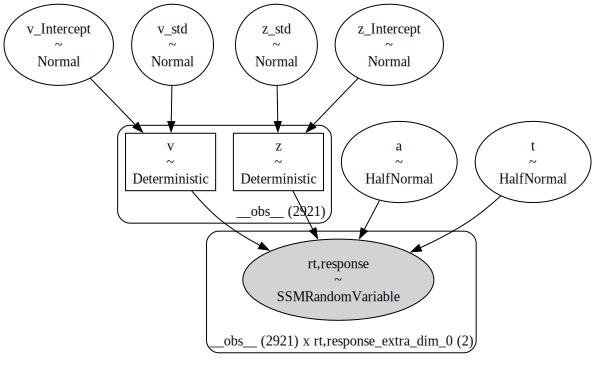

In [8]:
model_1.graph()

In [9]:
trace_model_1 = model_1.sample(
    #sampler="mcmc",  # type of sampler to choose, 'nuts_numpyro',
    # 'nuts_blackjax' of default pymc nuts sampler
    cores=1,  # how many cores to use
    chains=3,  # how many chains to run
    draws=5000,  # number of draws 
    tune=5000,  # number of burn-in samples
    idata_kwargs=dict(log_likelihood=True),  # return log likelihood
)  # mp_ctx="forkserver")

Using default initvals. 



Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (3 chains in 1 job)
NUTS: [a, t, v_Intercept, v_std, z_Intercept, z_std]


Output()

Output()

Output()

Sampling 3 chains for 5_000 tune and 5_000 draw iterations (15_000 + 15_000 draws total) took 2371 seconds.
There were 36 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
100%|██████████| 15000/15000 [00:28<00:00, 524.22it/s]


In [12]:
#save inference data- hsssm doesn't allow models to be saved but we can save the inference data 
trace_model_1.to_netcdf('trace_model_1.nc', compress=False)

'trace_model_1.nc'

In [2]:
#load inference data
import arviz as az
trace_model_1 = az.from_netcdf('trace_model_1.nc')


In [21]:
import arviz as az
import arviz as az

stats=az.summary(
    trace_model_1,
    var_names=[var_name.name for var_name in model_1.pymc_model.free_RVs],
)
stats.to_csv('model_1_stats.csv')

az.summary(
    trace_model_1,
    var_names=[var_name.name for var_name in model_1.pymc_model.free_RVs],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.452,0.013,1.428,1.476,0.000,0.000,10352.0,7893.0,1.0
t,0.007,0.006,0.000,0.017,0.000,0.000,7027.0,5255.0,1.0
v_Intercept,1.905,0.141,1.639,2.170,0.001,0.001,9691.0,10551.0,1.0
v_std,-4.294,0.472,-5.167,-3.398,0.005,0.003,9987.0,10214.0,1.0
z_Intercept,0.457,0.048,0.367,0.547,0.000,0.000,10054.0,9711.0,1.0
z_std,-0.235,0.161,-0.547,0.062,0.002,0.001,10285.0,10003.0,1.0


array([[<Axes: title={'center': 'v_Intercept'}>,
        <Axes: title={'center': 'v_Intercept'}>],
       [<Axes: title={'center': 'z_std'}>,
        <Axes: title={'center': 'z_std'}>],
       [<Axes: title={'center': 'v_std'}>,
        <Axes: title={'center': 'v_std'}>],
       [<Axes: title={'center': 'a'}>, <Axes: title={'center': 'a'}>],
       [<Axes: title={'center': 'z_Intercept'}>,
        <Axes: title={'center': 'z_Intercept'}>],
       [<Axes: title={'center': 't'}>, <Axes: title={'center': 't'}>]],
      dtype=object)

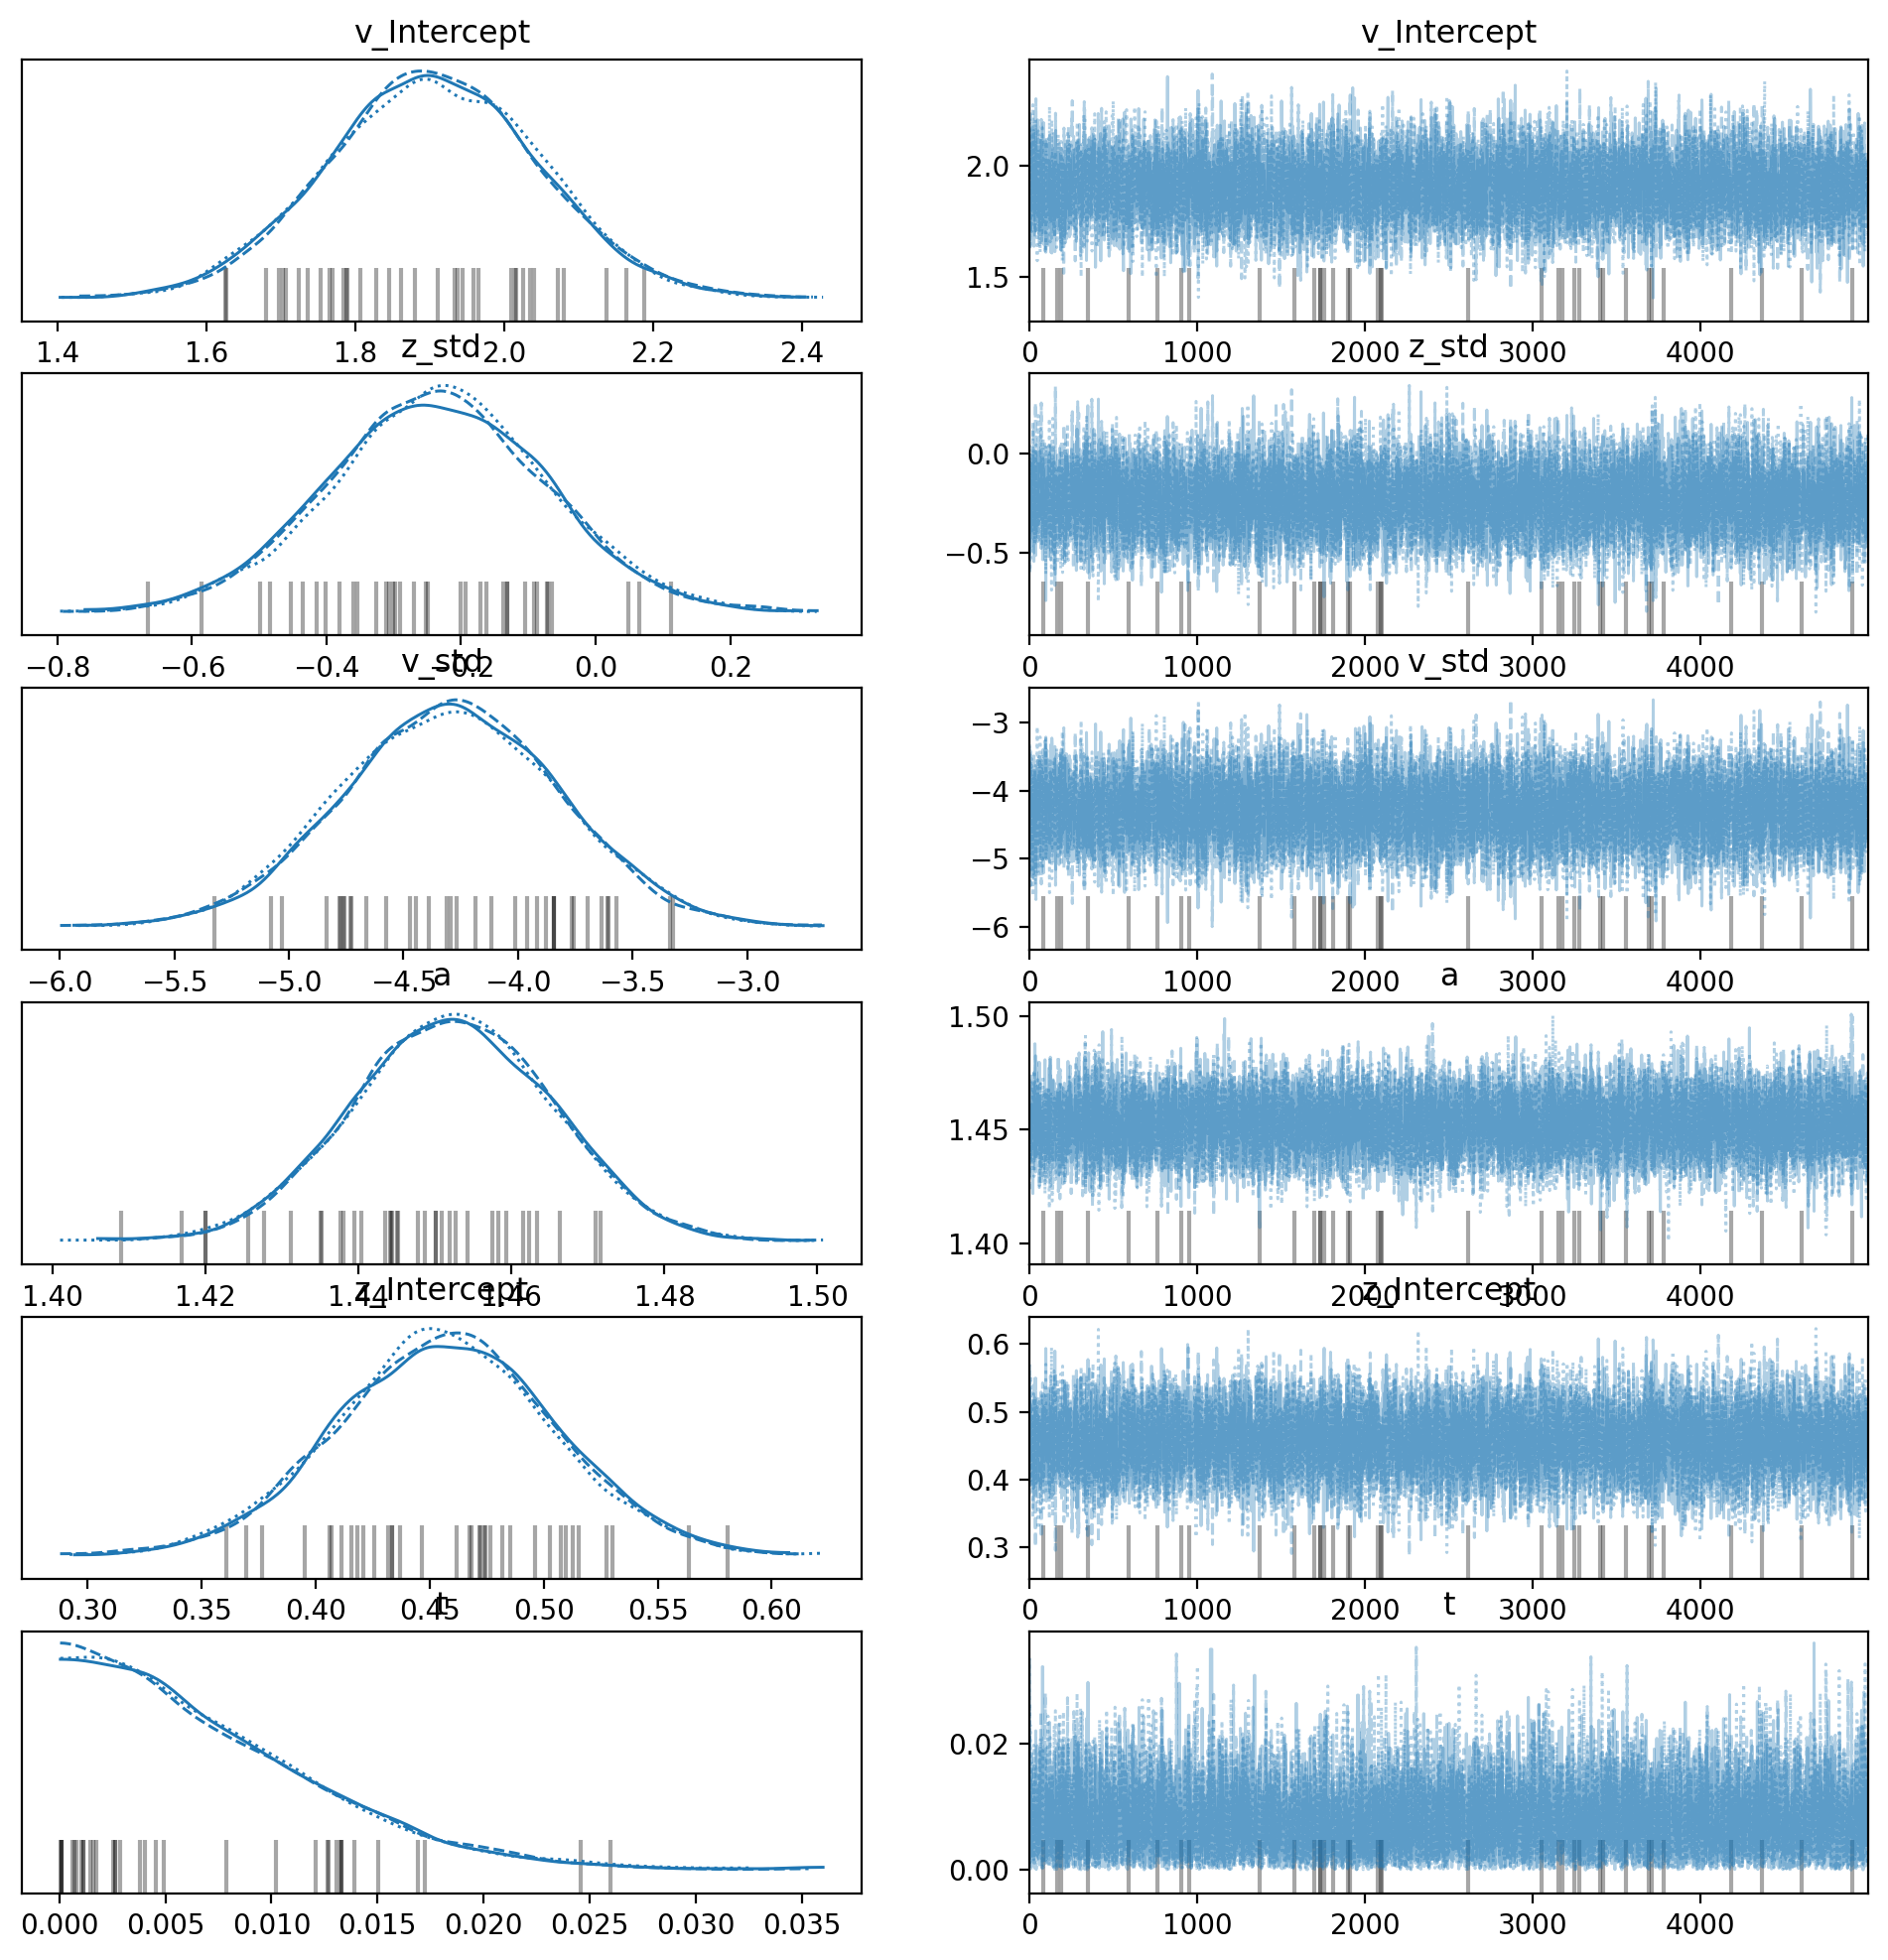

In [15]:
import arviz as az
import matplotlib as plt

az.plot_trace(
    trace_model_1 # we exclude the log_likelihood traces here
   
)


In [3]:

# Calculate the log likelihood using the log_likelihood method of the InferenceData object
log_likelihood = trace_model_1.log_likelihood

# Compute the marginal likelihood (also known as the log pointwise predictive density)
marginal_likelihood = log_likelihood.sum()

# Optionally, you can calculate the effective number of parameters (p_waic)
p_waic = az.waic(trace_model_1).p_waic

# Optionally, you can calculate the Widely Applicable Information Criterion (WAIC)
waic = az.waic(trace_model_1, scale='deviance')


print("Log likelihood:", log_likelihood.draw.mean())
print("Marginal likelihood (Log pointwise predictive density):", marginal_likelihood)
print("Effective number of parameters (p_waic):", p_waic)
print("WAIC:", waic)

Log likelihood: <xarray.DataArray 'draw' ()> Size: 8B
array(2499.5)
Marginal likelihood (Log pointwise predictive density): <xarray.Dataset> Size: 8B
Dimensions:      ()
Data variables:
    rt,response  float64 8B -8.396e+07
Effective number of parameters (p_waic): 5.239516259096874
WAIC: Computed from 15000 posterior samples and 2921 observations log-likelihood matrix.

              Estimate       SE
deviance_waic 11200.17   103.28
p_waic            5.24        -


In [4]:
def dic(inference_data):
    """
    Calculate the Deviance Information Criterion (DIC) for a given model.

    Parameters:
    inference_data (arviz.InferenceData): An ArviZ InferenceData object containing the posterior samples

    Returns:
    float: The computed DIC value.
    """

    # Extract log likelihood from the inference data
    log_likelihood = inference_data.log_likelihood

    # Calculate the point-wise deviance
    D_bar = -2 * np.mean(log_likelihood)

    # Calculate the effective number of parameters
    p_D = 2 * (D_bar + 2 * np.mean(log_likelihood) - np.mean(log_likelihood))

    # Calculate DIC
    dic = D_bar + p_D

    return dic

dic=dic(trace_model_1)
print("DIC:", dic)

DIC: <xarray.Dataset> Size: 8B
Dimensions:      ()
Data variables:
    rt,response  float64 8B 7.665


array([[<Axes: title={'center': 'v_Intercept'}>,
        <Axes: title={'center': 'z_std'}>,
        <Axes: title={'center': 'v_std'}>],
       [<Axes: title={'center': 'a'}>,
        <Axes: title={'center': 'z_Intercept'}>,
        <Axes: title={'center': 't'}>]], dtype=object)

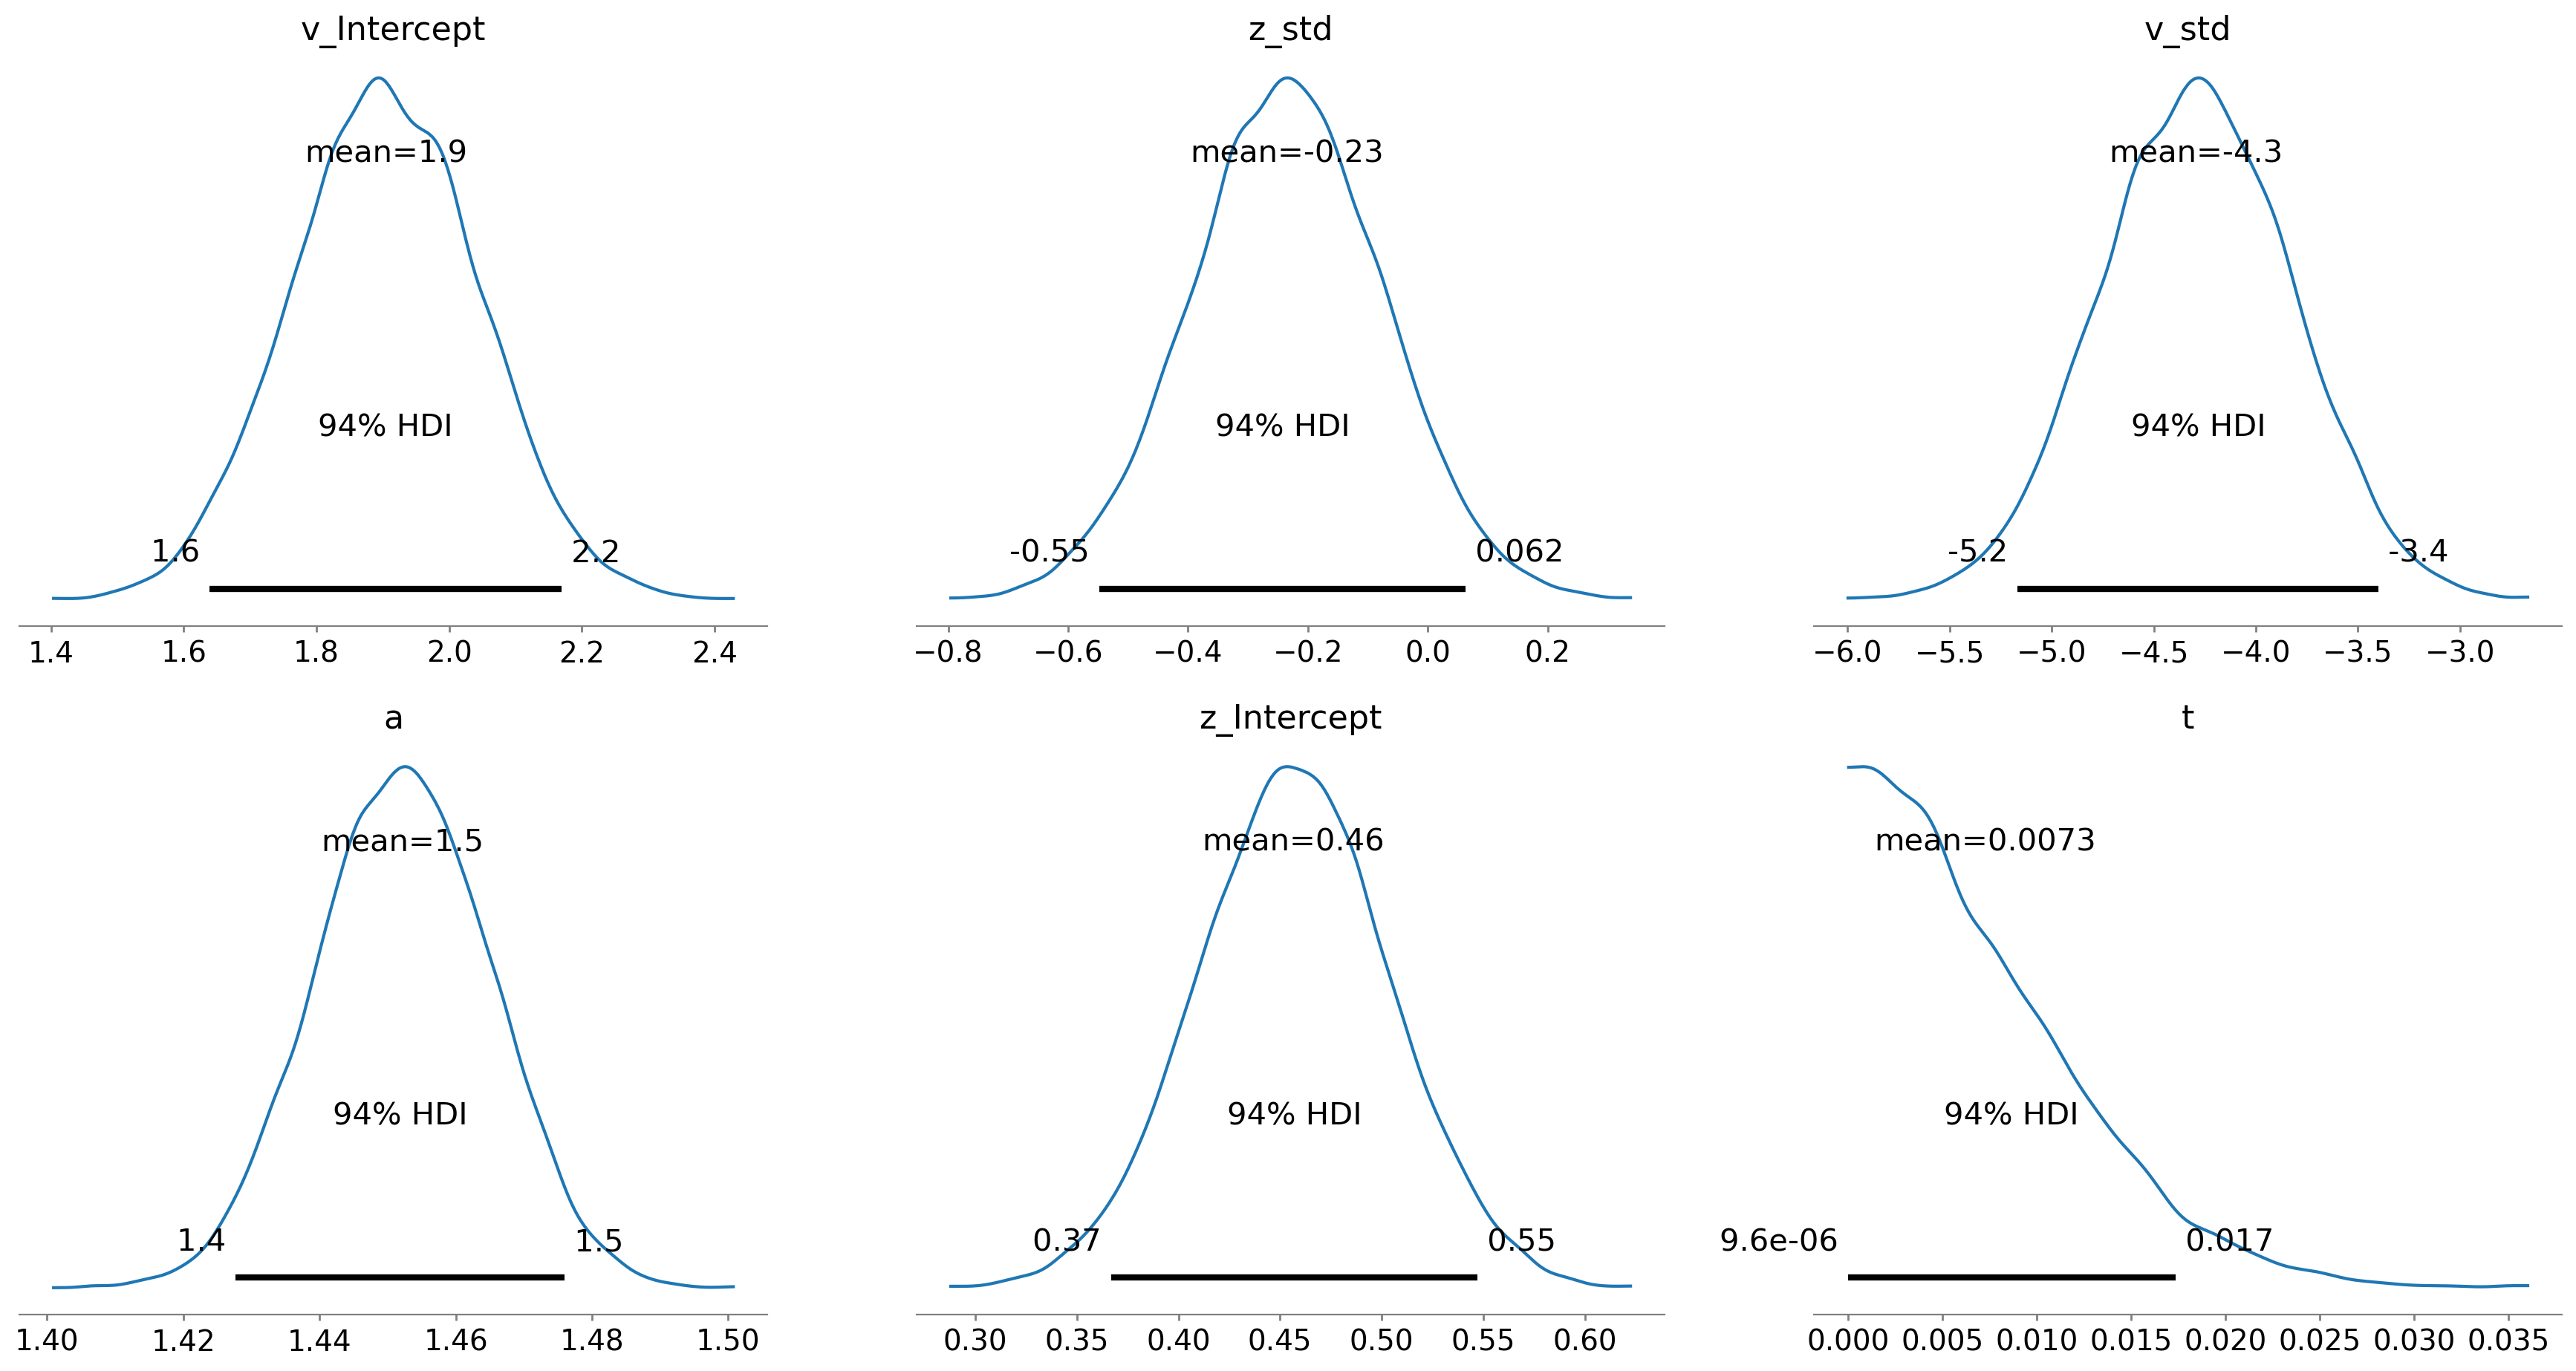

In [18]:
az.plot_posterior(model_1.traces)

No posterior predictive samples found. Generating posterior predictive samples using the provided InferenceData object and the original data. This will modify the provided InferenceData object, or if not provided, the traces object stored inside the model.


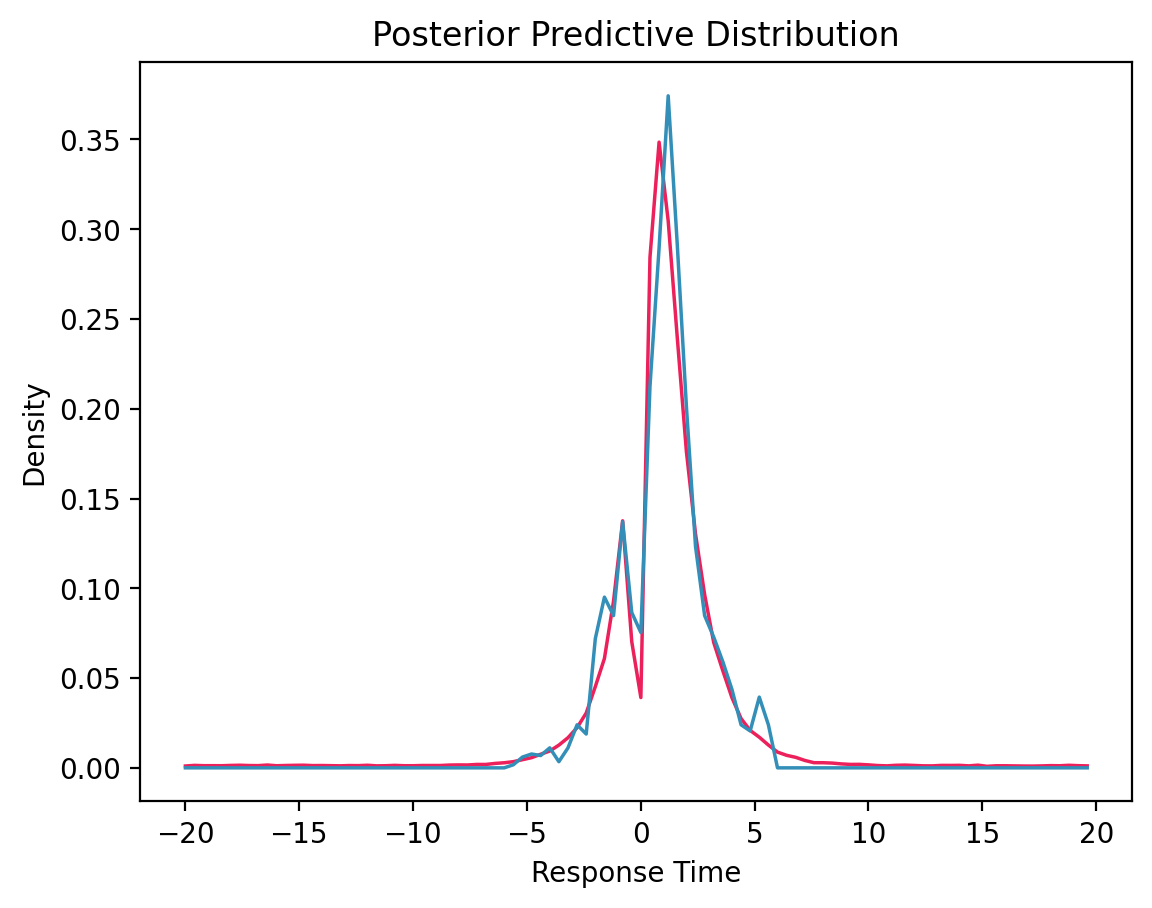

In [34]:
hssm.plotting.plot_posterior_predictive(model_1);


Text(0, 0.5, '')

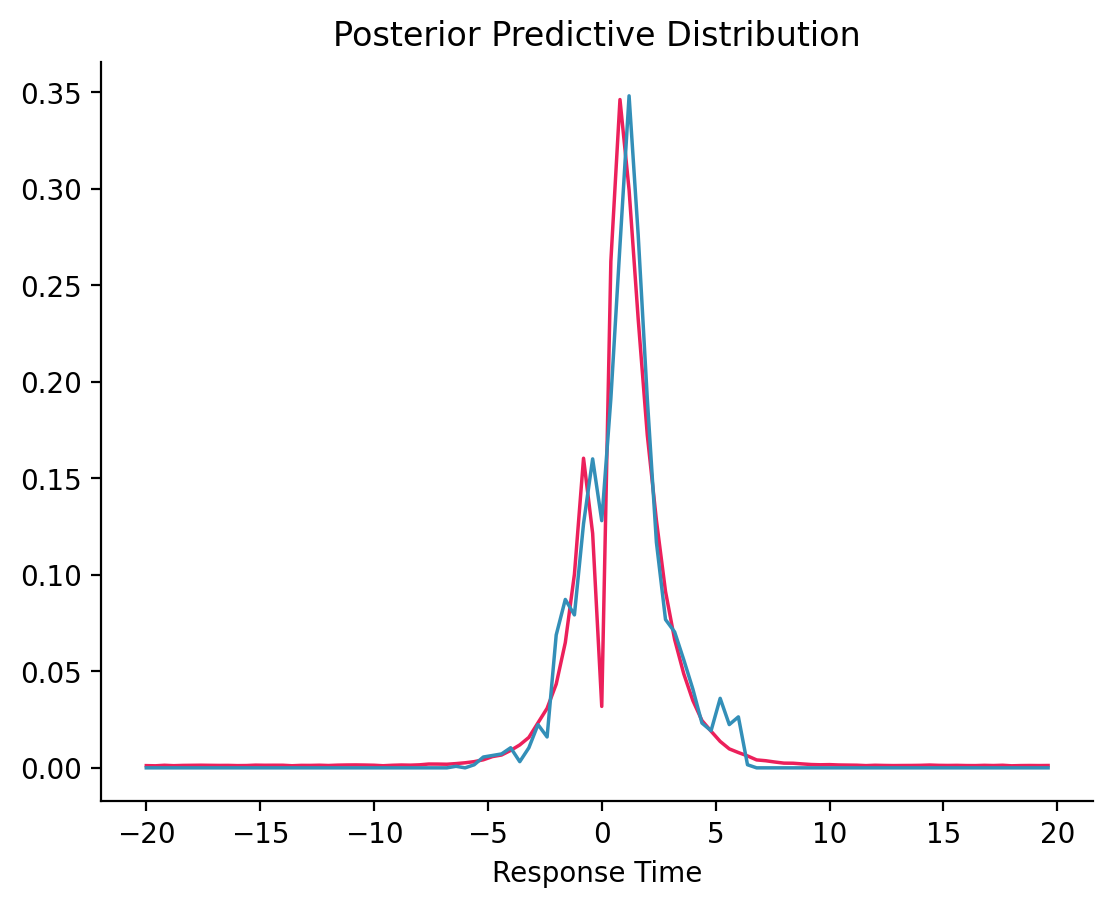

In [16]:
import seaborn as sns
ax = hssm.plotting.plot_posterior_predictive(model_1)
sns.despine()
ax.set_ylabel("")
